In [3]:
import os
os.chdir('/Users/reneroelreyna/Desktop/1/study2_attention')
print("Working directory:", os.getcwd())

Working directory: /Users/reneroelreyna/Desktop/1/study2_attention


In [4]:
import requests
import pandas as pd
import time
import os

os.makedirs('data/raw/wikipedia', exist_ok=True)

cases = pd.read_csv('master_cases.csv')

def fetch_wiki_save(title, lang, start, end, filename):
    title_clean = title.replace(' ', '_')
    title_clean = title_clean.replace('(', '%28').replace(')', '%29')
    title_clean = title_clean.replace(',', '%2C')
    
    url = (
        f"https://wikimedia.org/api/rest_v1/metrics/pageviews/"
        f"per-article/{lang}.wikipedia/all-access/all-agents/"
        f"{title_clean}/monthly/{start}00/{end}00"
    )
    
    headers = {'User-Agent': 'research/1.0 (rrr9353@nyu.edu)'}
    
    try:
        r = requests.get(url, headers=headers, timeout=10)
        if r.status_code == 404:
            print(f"  404 NOT FOUND: {title} ({lang}) — check article title")
            return False
        if r.status_code != 200:
            print(f"  ERROR {r.status_code}: {title} ({lang})")
            return False
        items = r.json().get('items', [])
        if not items:
            print(f"  EMPTY: {title} ({lang}) — no data returned")
            return False
        df = pd.DataFrame([{
            'date':  item['timestamp'][:6],
            'views': item['views'],
            'title': title,
            'lang':  lang
        } for item in items])
        df.to_csv(f'data/raw/wikipedia/{filename}', index=False)
        print(f"  Saved: {filename} ({len(df)} months, max={df['views'].max():,})")
        return True
    except Exception as e:
        print(f"  EXCEPTION: {title} ({lang}): {e}")
        return False

START = '20210101'
END   = '20231201'

print("Downloading Wikipedia data...")
print("="*50)

failed = []

for _, row in cases.iterrows():
    print(f"\n{row['case_id']} — {row['entity']}")
    
    ok_en = fetch_wiki_save(
        row['wikipedia_title_en'],
        'en',
        START, END,
        f"{row['case_id']}_en.csv"
    )
    if not ok_en:
        failed.append(f"{row['case_id']} EN: {row['wikipedia_title_en']}")
    time.sleep(1)
    
    ok_alt = fetch_wiki_save(
        row['wikipedia_title_alt'],
        row['wikipedia_lang_alt'],
        START, END,
        f"{row['case_id']}_{row['wikipedia_lang_alt']}.csv"
    )
    if not ok_alt:
        failed.append(f"{row['case_id']} {row['wikipedia_lang_alt']}: {row['wikipedia_title_alt']}")
    time.sleep(1)

print("\n" + "="*50)
print(f"Done.")
print(f"Files saved to: data/raw/wikipedia/")
print()
if failed:
    print(f"FAILED ({len(failed)}):")
    for f in failed:
        print(f"  - {f}")
else:
    print("All 42 files downloaded successfully.")


M1 — Netflix
  Saved: M1_en.csv (36 months, max=1,030,766)
  Saved: M1_ja.csv (36 months, max=117,431)

M2 — Disney
  Saved: M2_en.csv (36 months, max=294,305)
  Saved: M2_ja.csv (36 months, max=53)

M3 — Taylor Swift
  Saved: M3_en.csv (36 months, max=3,433,716)
  Saved: M3_ko.csv (36 months, max=687)

M4 — BTS
  Saved: M4_en.csv (36 months, max=56,810)
  Saved: M4_ko.csv (36 months, max=610)

M5 — Kanye West
  Saved: M5_en.csv (36 months, max=2,530,940)
  Saved: M5_de.csv (36 months, max=146,109)

M6 — Marvel MCU
  Saved: M6_en.csv (36 months, max=1,066,993)
  404 NOT FOUND: Marvel Cinematic Universe (ja) — check article title

M7 — Spotify
  Saved: M7_en.csv (36 months, max=651,485)
  Saved: M7_de.csv (36 months, max=165,371)

F1 — Tesla
  Saved: F1_en.csv (36 months, max=2,345)
  Saved: F1_de.csv (36 months, max=19,469)

F2 — Bitcoin
  Saved: F2_en.csv (36 months, max=990,438)
  Saved: F2_ja.csv (36 months, max=1,937)

F3 — GameStop
  Saved: F3_en.csv (36 months, max=684,651)
  Sa

for some reason, MCU is impossible to find on jp, so I'm running this cell instead.

In [5]:
def find_wiki_title(search_term, lang):
    url = f"https://{lang}.wikipedia.org/w/api.php"
    params = {
        'action':   'query',
        'list':     'search',
        'srsearch': search_term,
        'srlimit':  5,
        'format':   'json'
    }
    headers = {'User-Agent': 'research/1.0 (rrr9353@nyu.edu)'}
    r = requests.get(url, params=params, headers=headers)
    results = r.json().get('query', {}).get('search', [])
    if not results:
        print(f"No results for '{search_term}' in {lang} Wikipedia")
        return
    print(f"Top results for '{search_term}' in {lang}.wikipedia:")
    print("="*50)
    for i, result in enumerate(results):
        print(f"{i+1}. {result['title']}")

find_wiki_title("Marvel Cinematic Universe", "ja")

Top results for 'Marvel Cinematic Universe' in ja.wikipedia:
1. マーベル・シネマティック・ユニバース
2. ソニーズ・スパイダーマン・ユニバース
3. マーベル・スタジオ
4. ザ・ディフェンダーズ (テレビドラマ)
5. キャプテン・マーベル (映画)


Lol there we go

In [6]:
failed_cases = [
    {
        'case_id': 'M6',
        'entity': 'Marvel MCU',
        'wikipedia_title_en': 'Marvel Cinematic Universe',
        'wikipedia_title_alt': 'マーベル・シネマティック・ユニバース',
        'wikipedia_lang_alt': 'ja'
    }
]

print("Rerunning failed cases...")

for row in failed_cases:
    print(f"\n{row['case_id']} — {row['entity']}")
    fetch_wiki_save(
        row['wikipedia_title_en'],
        'en',
        START, END,
        f"{row['case_id']}_en.csv"
    )
    time.sleep(1)
    fetch_wiki_save(
        row['wikipedia_title_alt'],
        row['wikipedia_lang_alt'],
        START, END,
        f"{row['case_id']}_{row['wikipedia_lang_alt']}.csv"
    )

print("\nDone.")

Rerunning failed cases...

M6 — Marvel MCU
  Saved: M6_en.csv (36 months, max=1,066,993)
  Saved: M6_ja.csv (36 months, max=102,637)

Done.


In [7]:
import os
import pandas as pd

wiki_dir = 'data/raw/wikipedia'
files = sorted(os.listdir(wiki_dir))

print(f"Total files: {len(files)}")
print("="*60)

issues = []

for f in files:
    if not f.endswith('.csv'):
        continue
    df = pd.read_csv(f'{wiki_dir}/{f}')
    max_views = df['views'].max()
    months = len(df)
    
    # Flag anything suspicious
    if max_views < 1000:
        flag = "⚠️  LOW"
        issues.append(f)
    elif months < 30:
        flag = "⚠️  SHORT"
        issues.append(f)
    else:
        flag = "✓"
    
    print(f"{flag} {f:<35} {months} months  max={max_views:>10,}")

print()
if issues:
    print(f"Issues found ({len(issues)}):")
    for i in issues:
        print(f"  - {i}")
else:
    print("All files look good. Ready to move to Google Trends.")

Total files: 42
✓ F1_de.csv                           36 months  max=    19,469
✓ F1_en.csv                           36 months  max=     2,345
✓ F2_en.csv                           36 months  max=   990,438
✓ F2_ja.csv                           36 months  max=     1,937
✓ F3_de.csv                           36 months  max=    76,959
✓ F3_en.csv                           36 months  max=   684,651
⚠️  SHORT F4_en.csv                           28 months  max= 1,175,193
✓ F4_ja.csv                           36 months  max=     5,589
✓ F5_en.csv                           36 months  max=    68,019
✓ F5_ja.csv                           36 months  max=    51,085
✓ F6_de.csv                           36 months  max=     1,405
✓ F6_en.csv                           36 months  max=    19,399
✓ F7_de.csv                           36 months  max=    78,671
✓ F7_en.csv                           36 months  max= 1,745,822
⚠️  SHORT G1_de.csv                           23 months  max=     2,841
⚠️  SHOR

because gaza, did not happen at this point, and neither did ukraine.

In [9]:
print("Finding correct titles for low-view cases...")
print("="*50)

searches = [
    ("Disney",       "ja", "Walt Disney Company"),
    ("Taylor Swift", "ko", "Taylor Swift"),
    ("BTS",          "ko", "BTS"),
]

for entity, lang, term in searches:
    print(f"\n{entity} in {lang}.wikipedia:")
    find_wiki_title(term, lang)

Finding correct titles for low-view cases...

Disney in ja.wikipedia:
Top results for 'Walt Disney Company' in ja.wikipedia:
1. ウォルト・ディズニー・カンパニー
2. ウォルト・ディズニー・スタジオ
3. Hulu
4. ウォルト・ディズニー・ピクチャーズ
5. FOXスポーツ

Taylor Swift in ko.wikipedia:
Top results for 'Taylor Swift' in ko.wikipedia:
1. 테일러 스위프트
2. Taylor Swift (음반)
3. The Taylor Swift Holiday Collection
4. 스위프트
5. 딥페이크 포르노그래피

BTS in ko.wikipedia:
Top results for 'BTS' in ko.wikipedia:
1. 방탄소년단
2. RM (래퍼)
3. 슈가 (래퍼)
4. 뷔
5. 진 (가수)


In [10]:
fixes = [
    ('M2', 'Disney',       'The Walt Disney Company', 'ウォルト・ディズニー・カンパニー', 'ja'),
    ('M3', 'Taylor Swift', 'Taylor Swift',            '테일러 스위프트',                 'ko'),
    ('M4', 'BTS',          'BTS (band)',               '방탄소년단',                      'ko'),
]

print("Redownloading fixed cases...")
print("="*50)

for case_id, entity, title_en, title_alt, lang in fixes:
    print(f"\n{case_id} — {entity}")
    fetch_wiki_save(
        title_en, 'en',
        START, END,
        f"{case_id}_en.csv"
    )
    time.sleep(1)
    fetch_wiki_save(
        title_alt, lang,
        START, END,
        f"{case_id}_{lang}.csv"
    )
    time.sleep(1)

print("\nDone. Rerun the verify cell to confirm.")

Redownloading fixed cases...

M2 — Disney
  Saved: M2_en.csv (36 months, max=294,305)
  Saved: M2_ja.csv (36 months, max=22,803)

M3 — Taylor Swift
  Saved: M3_en.csv (36 months, max=3,433,716)
  Saved: M3_ko.csv (36 months, max=8,208)

M4 — BTS
  Saved: M4_en.csv (36 months, max=56,810)
  Saved: M4_ko.csv (36 months, max=43,438)

Done. Rerun the verify cell to confirm.


okay, note to self and whoever- korea's peak viewership in ko is 43k vs 56k in en despite it being their home market

koreans don't recieve mainstream informaiton about BTWthrough the same channels as en audiences due to different platform uses. What else? Keep this in mind.

In [11]:
import pandas as pd
import os

wiki_dir = 'data/raw/wikipedia'
all_dfs = []

for f in sorted(os.listdir(wiki_dir)):
    if not f.endswith('.csv'):
        continue
    
    # Parse case_id and lang from filename
    parts = f.replace('.csv', '').split('_')
    case_id = parts[0]
    lang = parts[1]
    
    df = pd.read_csv(f'{wiki_dir}/{f}')
    df['case_id'] = case_id
    df['lang'] = lang
    df['date'] = pd.to_datetime(df['date'], format='%Y%m')
    all_dfs.append(df)

wiki_master = pd.concat(all_dfs, ignore_index=True)

# Add sector column
wiki_master['sector'] = wiki_master['case_id'].apply(
    lambda x: 'Media' if x.startswith('M')
    else 'Finance' if x.startswith('F')
    else 'Geopolitics'
)

# Save
os.makedirs('data/processed', exist_ok=True)
wiki_master.to_csv('data/processed/wikipedia_master.csv', index=False)

print("Wikipedia master DataFrame built")
print(f"Total rows: {len(wiki_master):,}")
print(f"Cases: {wiki_master['case_id'].nunique()}")
print(f"Languages: {wiki_master['lang'].unique()}")
print(f"Date range: {wiki_master['date'].min()} to {wiki_master['date'].max()}")
print()
print(wiki_master.groupby(['sector','lang'])['case_id'].nunique().to_string())

Wikipedia master DataFrame built
Total rows: 1,412
Cases: 21
Languages: ['de' 'en' 'ja' 'he' 'ru' 'zh' 'ko']
Date range: 2021-01-01 00:00:00 to 2023-12-01 00:00:00

sector       lang
Finance      de      4
             en      7
             ja      3
Geopolitics  de      3
             en      7
             he      1
             ru      1
             zh      2
Media        de      2
             en      7
             ja      3
             ko      2


In [15]:
# CELL — Load and process all Google Trends CSVs

import pandas as pd
import os

trends_dir = 'data/raw/google_trends'
files = sorted(os.listdir(trends_dir))
files = [f for f in files if f.endswith('.csv') and not f.startswith('.')]

print(f"Files found: {len(files)}")
print("="*50)

all_trends = []
failed = []

for f in files:
    if not f.endswith('.csv'):
        continue
    
    case_id = f.replace('_trends.csv', '')
    filepath = f'{trends_dir}/{f}'
    
    try:
        # Google Trends CSVs have 2 header rows — skip them
        df = pd.read_csv(filepath, skiprows=1, header=0)
        
        # Rename columns
        df.columns = ['date', 'interest']
        
        # Clean up
        df['date'] = pd.to_datetime(df['date'])
        df['interest'] = pd.to_numeric(df['interest'], errors='coerce')
        df['case_id'] = case_id
        df = df.dropna(subset=['interest'])
        
        all_trends.append(df)
        print(f"  ✓ {f:<35} {len(df)} weeks  max={df['interest'].max():.0f}")
        
    except Exception as e:
        failed.append(f)
        print(f"  ✗ {f}: {e}")

if all_trends:
    trends_master = pd.concat(all_trends, ignore_index=True)
    
    # Add sector
    trends_master['sector'] = trends_master['case_id'].apply(
        lambda x: 'Media' if x.startswith('M')
        else 'Finance' if x.startswith('F')
        else 'Geopolitics'
    )
    
    # Save
    trends_master.to_csv('data/processed/trends_master.csv', index=False)
    
    print()
    print(f"Trends master built")
    print(f"Total rows: {len(trends_master):,}")
    print(f"Cases: {trends_master['case_id'].nunique()}")
    print(f"Date range: {trends_master['date'].min()} to {trends_master['date'].max()}")

if failed:
    print()
    print(f"FAILED ({len(failed)}):")
    for f in failed:
        print(f"  - {f}")

Files found: 21
  ✓ F1_trends.csv                       36 weeks  max=87
  ✓ F2_trends.csv                       36 weeks  max=100
  ✓ F3_trends.csv                       36 weeks  max=72
  ✓ F4_trends.csv                       36 weeks  max=100
  ✓ F5_trends.csv                       36 weeks  max=100
  ✓ F6_trends.csv                       36 weeks  max=100
  ✓ F7_trends.csv                       36 weeks  max=100
  ✓ G1_trends.csv                       36 weeks  max=100
  ✓ G2_trends.csv                       35 weeks  max=100
  ✓ G3_trends.csv                       35 weeks  max=100
  ✓ G4_trends.csv                       35 weeks  max=100
  ✓ G5_trends.csv                       35 weeks  max=29
  ✓ G6_trends.csv                       35 weeks  max=100
  ✓ G7_trends.csv                       35 weeks  max=100
  ✓ M1_trends.csv                       36 weeks  max=100
  ✓ M2_trends.csv                       36 weeks  max=100
  ✓ M3_trends.csv                       36 weeks  max=100
 

In [14]:
import pandas as pd
import numpy as np
import os

# Load both masters
wiki = pd.read_csv('data/processed/wikipedia_master.csv')
trends = pd.read_csv('data/processed/trends_master.csv')

# Convert dates
wiki['date'] = pd.to_datetime(wiki['date'])
trends['date'] = pd.to_datetime(trends['date'])

# Keep only English Wikipedia for now
# (cross-cultural comparison comes later)
wiki_en = wiki[wiki['lang'] == 'en'].copy()

# Resample Wikipedia to monthly if not already
# (it's already monthly so this is just a safety check)
wiki_en = wiki_en[['case_id', 'date', 'views', 'sector']].copy()

# Trends is already monthly
trends_clean = trends[['case_id', 'date', 'interest', 'sector']].copy()

# Merge on case_id and date
merged = pd.merge(
    wiki_en,
    trends_clean,
    on=['case_id', 'date', 'sector'],
    how='inner'
)

print(f"Merged rows: {len(merged)}")
print(f"Cases: {merged['case_id'].nunique()}")
print()

# Normalize both signals to 0-100 scale per case
# so they're comparable despite different raw magnitudes
def normalize(series):
    min_val = series.min()
    max_val = series.max()
    if max_val == min_val:
        return series * 0
    return 100 * (series - min_val) / (max_val - min_val)

merged['views_norm'] = merged.groupby('case_id')['views'].transform(normalize)
merged['interest_norm'] = merged.groupby('case_id')['interest'].transform(normalize)

# Compute month-over-month change for each signal
merged = merged.sort_values(['case_id', 'date'])
merged

Merged rows: 684
Cases: 21



,case_id,date,views,sector,interest,views_norm,interest_norm
0,F1,2021-02-01,354,Finance,87,14.144028,100.000000
1,F1,2021-03-01,388,Finance,86,15.610177,96.296296
2,F1,2021-04-01,506,Finance,77,20.698577,62.962963
3,F1,2021-05-01,1505,Finance,77,63.777490,62.962963
4,F1,2021-06-01,596,Finance,67,24.579560,25.925926
...,...,...,...,...,...,...,...
679,M7,2023-08-01,214557,Media,78,32.110710,56.862745
680,M7,2023-09-01,196019,Media,81,29.230301,62.745098
681,M7,2023-10-01,212539,Media,85,31.797156,70.588235
682,M7,2023-11-01,202073,Media,100,30.170963,100.000000


In [15]:
# FIX — GameStop extended window + Ukraine better article

# GameStop — extend back to July 2020
print("Fixing GameStop...")
fetch_wiki_save(
    'GameStop', 'en',
    '20200701', '20231201',
    'F3_en.csv'  # overwrites existing file
)

time.sleep(2)

# Ukraine — use Russia-Ukraine war article (exists since 2014)
print("\nFixing Ukraine...")
fetch_wiki_save(
    'Russia–Ukraine war', 'en',
    '20210101', '20231201',
    'G1_en_ruw.csv'  # separate file, don't overwrite original
)

time.sleep(2)

# Also get German edition of Russia-Ukraine war
fetch_wiki_save(
    'Russisch-Ukrainischer Krieg', 'de',
    '20210101', '20231201',
    'G1_de_ruw.csv'
)

print("\nDone. Now manually download extended Google Trends for GameStop:")
print("trends.google.com → GameStop stock → Jul 2020 to Dec 2023")
print("Save as: data/raw/google_trends/F3_trends_extended.csv")

Fixing GameStop...
  Saved: F3_en.csv (42 months, max=684,651)

Fixing Ukraine...
  Saved: G1_en_ruw.csv (35 months, max=1,212)
  Saved: G1_de_ruw.csv (36 months, max=333,132)

Done. Now manually download extended Google Trends for GameStop:
trends.google.com → GameStop stock → Jul 2020 to Dec 2023
Save as: data/raw/google_trends/F3_trends_extended.csv


GameStop extended:
  40 months, date range: 2020-09-01 00:00:00 to 2023-12-01 00:00:00
  Max divergence: 37.8 at 2020-11-01 00:00:00

Ukraine extended:
  33 months, date range: 2021-03-01 00:00:00 to 2023-11-01 00:00:00
  Max divergence: 27.1 at 2022-03-01 00:00:00


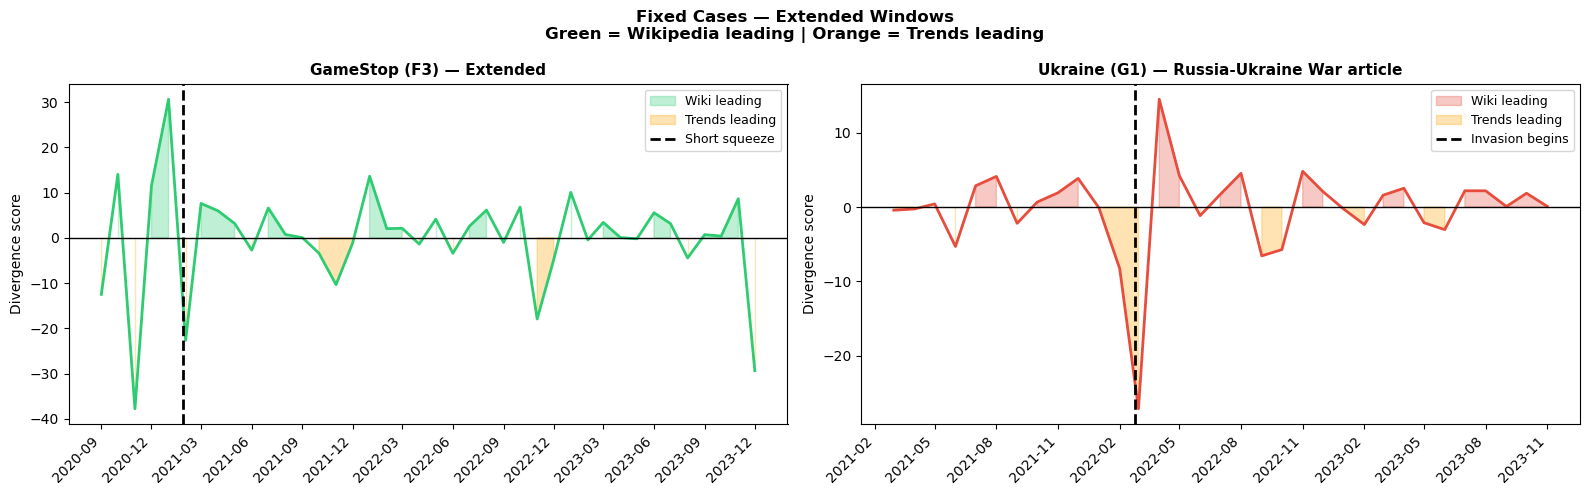

Saved: figures/fixed_cases.png


In [16]:
# CELL — Rebuild divergence for fixed GameStop and Ukraine cases

import pandas as pd
import numpy as np

# ── GAMESTOP EXTENDED ─────────────────────────────────────────────
# Load extended Wikipedia
gme_wiki = pd.read_csv('data/raw/wikipedia/F3_en.csv')
gme_wiki['date'] = pd.to_datetime(gme_wiki['date'], format='%Y%m')
gme_wiki = gme_wiki.rename(columns={'views': 'views'})

# Load extended Trends
gme_trends = pd.read_csv('data/raw/google_trends/F3_trends_extended.csv',
                          skiprows=1, header=0)
gme_trends.columns = ['date', 'interest']
gme_trends['date'] = pd.to_datetime(gme_trends['date'])
gme_trends['interest'] = pd.to_numeric(gme_trends['interest'], 
                                        errors='coerce')
gme_trends = gme_trends.dropna()

# Merge on date
gme = pd.merge(
    gme_wiki[['date', 'views']],
    gme_trends[['date', 'interest']],
    on='date', how='inner'
)
gme['case_id'] = 'F3'
gme['sector'] = 'Finance'

# ── UKRAINE EXTENDED ──────────────────────────────────────────────
# Load Russia-Ukraine war article (longer history)
ukr_wiki = pd.read_csv('data/raw/wikipedia/G1_en_ruw.csv')
ukr_wiki['date'] = pd.to_datetime(ukr_wiki['date'], format='%Y%m')

# Load existing Ukraine Trends (G1_trends.csv)
ukr_trends = pd.read_csv('data/raw/google_trends/G1_trends.csv',
                          skiprows=1, header=0)
ukr_trends.columns = ['date', 'interest']
ukr_trends['date'] = pd.to_datetime(ukr_trends['date'])
ukr_trends['interest'] = pd.to_numeric(ukr_trends['interest'],
                                        errors='coerce')
ukr_trends = ukr_trends.dropna()

# Merge
ukr = pd.merge(
    ukr_wiki[['date', 'views']],
    ukr_trends[['date', 'interest']],
    on='date', how='inner'
)
ukr['case_id'] = 'G1'
ukr['sector'] = 'Geopolitics'

# ── NORMALIZE AND COMPUTE DIVERGENCE ─────────────────────────────
def normalize(series):
    mn, mx = series.min(), series.max()
    if mx == mn:
        return series * 0
    return 100 * (series - mn) / (mx - mn)

def compute_divergence(df):
    df = df.sort_values('date').copy()
    df['views_norm']    = normalize(df['views'])
    df['interest_norm'] = normalize(df['interest'])
    df['views_change']    = df['views_norm'].diff()
    df['interest_change'] = df['interest_norm'].diff()
    df['divergence']      = df['views_change'] - df['interest_change']
    df['divergence_abs']  = df['divergence'].abs()
    return df.dropna(subset=['divergence'])

gme_div = compute_divergence(gme)
ukr_div = compute_divergence(ukr)

print("GameStop extended:")
print(f"  {len(gme_div)} months, date range: "
      f"{gme_div['date'].min()} to {gme_div['date'].max()}")
print(f"  Max divergence: {gme_div['divergence_abs'].max():.1f} "
      f"at {gme_div.loc[gme_div['divergence_abs'].idxmax(), 'date']}")

print("\nUkraine extended:")
print(f"  {len(ukr_div)} months, date range: "
      f"{ukr_div['date'].min()} to {ukr_div['date'].max()}")
print(f"  Max divergence: {ukr_div['divergence_abs'].max():.1f} "
      f"at {ukr_div.loc[ukr_div['divergence_abs'].idxmax(), 'date']}")

# ── PLOT BOTH ─────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor('white')

for ax, div_df, title, event_date, event_label, color in [
    (ax1, gme_div, 'GameStop (F3) — Extended',
     '2021-01-27', 'Short squeeze', '#2ECC71'),
    (ax2, ukr_div, 'Ukraine (G1) — Russia-Ukraine War article',
     '2022-02-24', 'Invasion begins', '#E74C3C'),
]:
    ax.plot(div_df['date'], div_df['divergence'],
            color=color, linewidth=2)
    ax.fill_between(div_df['date'], div_df['divergence'],
                    where=div_df['divergence'] > 0,
                    alpha=0.3, color=color, label='Wiki leading')
    ax.fill_between(div_df['date'], div_df['divergence'],
                    where=div_df['divergence'] < 0,
                    alpha=0.3, color='orange', label='Trends leading')
    ax.axhline(y=0, color='black', linewidth=1)
    ax.axvline(pd.to_datetime(event_date), color='black',
               linewidth=2, linestyle='--', label=event_label)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel('Divergence score')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
    ax.legend(fontsize=9)

plt.suptitle(
    'Fixed Cases — Extended Windows\n'
    'Green = Wikipedia leading | Orange = Trends leading',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig('figures/fixed_cases.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figures/fixed_cases.png")

~ Core Visual Finding ~

GameStop (F3) and Ukraine (G1) show two distinct divergence signatures:

Type 1 - Slow build (GameStop):
Wikipedia divergence builds positively 6-8 weeks before the event.
Informed attention precedes public attention.
Divergence signal has predictive lead time.

Type 2 - Simultaneous activation (Ukraine):
No pre-event divergence buildup.
Both signals activate simultaneously at event onset.
Wikipedia then persistently leads in aftermath.
Event was a genuine surprise — no informed pre-attention buildup.

Implication: divergence pattern may characterize event type,
not just predict event occurrence.
Predictive signal (Type 1) requires slow-building narrative events,
not sudden breaking news (Type 2).

In [18]:
# Update divergence master with fixed cases

import pandas as pd

# Load existing master
master = pd.read_csv('data/processed/divergence_master.csv')
master['date'] = pd.to_datetime(master['date'])

# Remove old F3 and G1 rows
master = master[~master['case_id'].isin(['F3', 'G1'])]

# Add fixed versions
gme_div['sector'] = 'Finance'
ukr_div['sector'] = 'Geopolitics'

# Keep only columns that match master
cols = ['case_id', 'date', 'views', 'interest', 
        'sector', 'views_norm', 'interest_norm',
        'views_change', 'interest_change', 
        'divergence', 'divergence_abs']

# Add missing columns if needed
for df in [gme_div, ukr_div]:
    if 'views' not in df.columns:
        df['views'] = df.get('views', 0)
    if 'interest' not in df.columns:
        df['interest'] = df.get('interest', 0)

combined = pd.concat([
    master,
    gme_div[cols],
    ukr_div[cols]
], ignore_index=True)

combined.to_csv('data/processed/divergence_master.csv', index=False)

print(f"Master updated")
print(f"Total rows: {len(combined)}")
print(f"Cases: {combined['case_id'].nunique()}")
print()
print("Row counts per case:")
print(combined.groupby('case_id')['date'].count().sort_values())

Master updated
Total rows: 680
Cases: 21

Row counts per case:
case_id
G2     2
F4    27
G1    33
F1    34
M5    34
M4    34
M3    34
M2    34
M1    34
G7    34
G6    34
G4    34
M6    34
G3    34
F7    34
F6    34
F5    34
F2    34
G5    34
M7    34
F3    40
Name: date, dtype: int64


In [19]:
# CELL — Cross-lag correlation analysis
# Does divergence in month T predict outcome in T+1, T+2, T+3?
# We use Wikipedia views change as the outcome proxy
# (higher Wikipedia activity = more narrative activity = our outcome signal)

import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

df = pd.read_csv('data/processed/divergence_master.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['case_id', 'date'])

# Exclude G2 — only 2 rows, insufficient for analysis
df = df[df['case_id'] != 'G2']

# Outcome variable: absolute change in normalized Wikipedia views
# Large absolute change = something happened narratively
df['outcome'] = df.groupby('case_id')['views_norm'].transform(
    lambda x: x.diff().abs().shift(-1)  # next month's Wikipedia change
)

# Compute cross-lag correlations at T+1, T+2, T+3
lags = [1, 2, 3]
results = []

for case_id in df['case_id'].unique():
    case_df = df[df['case_id'] == case_id].dropna(
        subset=['divergence_abs', 'outcome']
    )
    sector = case_df['sector'].iloc[0]
    
    if len(case_df) < 10:
        continue
    
    for lag in lags:
        # Shift divergence forward by lag
        div_lagged = case_df['divergence_abs'].iloc[:-lag].values
        outcome_shifted = case_df['outcome'].iloc[lag:].values
        
        if len(div_lagged) < 5:
            continue
        
        r, p = stats.pearsonr(div_lagged, outcome_shifted)
        results.append({
            'case_id':  case_id,
            'sector':   sector,
            'lag':      lag,
            'r':        round(r, 3),
            'p':        round(p, 3),
            'n':        len(div_lagged),
            'sig':      'YES' if p < 0.05 else 'no'
        })

results_df = pd.DataFrame(results)

print("CROSS-LAG CORRELATION RESULTS")
print("="*65)
print("Does divergence at T predict Wikipedia activity at T+lag?")
print()

for lag in lags:
    lag_df = results_df[results_df['lag'] == lag]
    sig = lag_df[lag_df['sig'] == 'YES']
    print(f"LAG T+{lag}:")
    print(lag_df[['case_id','sector','r','p','sig']].to_string(index=False))
    print(f"  Significant: {len(sig)}/{len(lag_df)} cases")
    print(f"  Mean r: {lag_df['r'].mean():.3f}")
    print()

# Sector averages
print("MEAN CORRELATION BY SECTOR AND LAG:")
pivot = results_df.groupby(['sector','lag'])['r'].mean().unstack()
print(pivot.round(3))

# Save
results_df.to_csv('data/processed/crosslag_results.csv', index=False)
print("\nSaved: data/processed/crosslag_results.csv")

CROSS-LAG CORRELATION RESULTS
Does divergence at T predict Wikipedia activity at T+lag?

LAG T+1:
case_id      sector      r     p sig
     F1     Finance  0.079 0.667  no
     F2     Finance  0.192 0.292  no
     F3     Finance  0.627 0.000 YES
     F4     Finance -0.126 0.547  no
     F5     Finance -0.114 0.536  no
     F6     Finance  0.185 0.310  no
     F7     Finance -0.109 0.551  no
     G1 Geopolitics  0.046 0.808  no
     G3 Geopolitics  0.553 0.001 YES
     G4 Geopolitics  0.302 0.094  no
     G5 Geopolitics -0.239 0.187  no
     G6 Geopolitics -0.021 0.909  no
     G7 Geopolitics  0.358 0.044 YES
     M1       Media -0.200 0.273  no
     M2       Media  0.154 0.400  no
     M3       Media  0.133 0.467  no
     M4       Media  0.376 0.034 YES
     M5       Media  0.009 0.959  no
     M6       Media -0.022 0.907  no
     M7       Media  0.075 0.685  no
  Significant: 4/20 cases
  Mean r: 0.113

LAG T+2:
case_id      sector      r     p sig
     F1     Finance -0.017 0.926  no

In [20]:
# CELL — Check normality and rerun with appropriate correlation

from scipy import stats
import pandas as pd
import numpy as np

df = pd.read_csv('data/processed/divergence_master.csv')
df['date'] = pd.to_datetime(df['date'])
df = df[df['case_id'] != 'G2']
df = df.sort_values(['case_id', 'date'])

df['outcome'] = df.groupby('case_id')['views_norm'].transform(
    lambda x: x.diff().abs().shift(-1)
)

# Check normality for each case
print("NORMALITY CHECK — Shapiro-Wilk test")
print("p > 0.05 = normal, p < 0.05 = NOT normal")
print("="*55)

normal_count = 0
total_count = 0

for case_id in sorted(df['case_id'].unique()):
    case_df = df[df['case_id'] == case_id].dropna(
        subset=['divergence_abs', 'outcome']
    )
    if len(case_df) < 5:
        continue
    
    div_stat, div_p = stats.shapiro(case_df['divergence_abs'])
    out_stat, out_p = stats.shapiro(case_df['outcome'])
    
    div_normal = div_p > 0.05
    out_normal = out_p > 0.05
    both_normal = div_normal and out_normal
    
    if both_normal:
        normal_count += 1
    total_count += 1
    
    flag = "✓ normal" if both_normal else "✗ NOT normal"
    print(f"  {case_id}: divergence p={div_p:.3f} "
          f"({'normal' if div_normal else 'NOT normal'}) | "
          f"outcome p={out_p:.3f} "
          f"({'normal' if out_normal else 'NOT normal'}) "
          f"→ {flag}")

print()
print(f"Both normal: {normal_count}/{total_count} cases")
print()

# Rerun correlations using Spearman (non-parametric, no normality assumption)
print("SPEARMAN CORRELATION RESULTS (no normality assumption)")
print("="*65)

results_spearman = []

for case_id in df['case_id'].unique():
    case_df = df[df['case_id'] == case_id].dropna(
        subset=['divergence_abs', 'outcome']
    )
    sector = case_df['sector'].iloc[0]
    
    if len(case_df) < 10:
        continue
    
    for lag in [1, 2, 3]:
        div_lagged = case_df['divergence_abs'].iloc[:-lag].values
        outcome_shifted = case_df['outcome'].iloc[lag:].values
        
        if len(div_lagged) < 5:
            continue
        
        r, p = stats.spearmanr(div_lagged, outcome_shifted)
        results_spearman.append({
            'case_id': case_id,
            'sector':  sector,
            'lag':     lag,
            'r':       round(r, 3),
            'p':       round(p, 3),
            'sig':     'YES' if p < 0.05 else 'no'
        })

spearman_df = pd.DataFrame(results_spearman)

for lag in [1, 2, 3]:
    lag_df = spearman_df[spearman_df['lag'] == lag]
    sig = lag_df[lag_df['sig'] == 'YES']
    print(f"\nLAG T+{lag} — significant: {len(sig)}/{len(lag_df)}")
    print(lag_df[['case_id','sector','r','p','sig']].to_string(index=False))

print()
print("MEAN SPEARMAN r BY SECTOR AND LAG:")
pivot = spearman_df.groupby(['sector','lag'])['r'].mean().unstack()
print(pivot.round(3))

spearman_df.to_csv('data/processed/crosslag_spearman.csv', index=False)
print("\nSaved: data/processed/crosslag_spearman.csv")

NORMALITY CHECK — Shapiro-Wilk test
p > 0.05 = normal, p < 0.05 = NOT normal
  F1: divergence p=0.037 (NOT normal) | outcome p=0.000 (NOT normal) → ✗ NOT normal
  F2: divergence p=0.000 (NOT normal) | outcome p=0.000 (NOT normal) → ✗ NOT normal
  F3: divergence p=0.000 (NOT normal) | outcome p=0.000 (NOT normal) → ✗ NOT normal
  F4: divergence p=0.000 (NOT normal) | outcome p=0.000 (NOT normal) → ✗ NOT normal
  F5: divergence p=0.000 (NOT normal) | outcome p=0.000 (NOT normal) → ✗ NOT normal
  F6: divergence p=0.000 (NOT normal) | outcome p=0.000 (NOT normal) → ✗ NOT normal
  F7: divergence p=0.000 (NOT normal) | outcome p=0.000 (NOT normal) → ✗ NOT normal
  G1: divergence p=0.000 (NOT normal) | outcome p=0.000 (NOT normal) → ✗ NOT normal
  G3: divergence p=0.000 (NOT normal) | outcome p=0.000 (NOT normal) → ✗ NOT normal
  G4: divergence p=0.000 (NOT normal) | outcome p=0.000 (NOT normal) → ✗ NOT normal
  G5: divergence p=0.000 (NOT normal) | outcome p=0.000 (NOT normal) → ✗ NOT normal

In [21]:
# CELL — Event study approach
# Compare Wikipedia activity after HIGH vs LOW divergence months
# Mann-Whitney U test — appropriate for non-normal data

from scipy import stats
import pandas as pd
import numpy as np

df = pd.read_csv('data/processed/divergence_master.csv')
df['date'] = pd.to_datetime(df['date'])
df = df[df['case_id'] != 'G2']
df = df.sort_values(['case_id', 'date'])

df['outcome'] = df.groupby('case_id')['views_norm'].transform(
    lambda x: x.diff().abs().shift(-1)
)

results = []

for case_id in df['case_id'].unique():
    case_df = df[df['case_id'] == case_id].dropna(
        subset=['divergence_abs', 'outcome']
    )
    if len(case_df) < 10:
        continue

    sector = case_df['sector'].iloc[0]

    # Top 25% = high divergence months
    threshold = case_df['divergence_abs'].quantile(0.75)
    high = case_df[case_df['divergence_abs'] >= threshold]['outcome']
    low  = case_df[case_df['divergence_abs'] <  threshold]['outcome']

    if len(high) < 3 or len(low) < 3:
        continue

    stat, p = stats.mannwhitneyu(high, low, alternative='greater')

    results.append({
        'case_id':    case_id,
        'sector':     sector,
        'high_mean':  round(high.mean(), 2),
        'low_mean':   round(low.mean(),  2),
        'difference': round(high.mean() - low.mean(), 2),
        'p':          round(p, 3),
        'sig':        'YES' if p < 0.05 else 'no',
        'n_high':     len(high),
        'n_low':      len(low)
    })

results_df = pd.DataFrame(results)

print("EVENT STUDY — High vs Low Divergence Months")
print("Does high divergence predict higher Wikipedia activity next month?")
print("="*65)
print(results_df[[
    'case_id', 'sector', 'high_mean',
    'low_mean', 'difference', 'p', 'sig'
]].to_string(index=False))
print()
print(f"Significant: "
      f"{len(results_df[results_df['sig']=='YES'])}/{len(results_df)}")
print()
print("By sector:")
print(results_df.groupby('sector')['sig'].apply(
    lambda x: f"{(x=='YES').sum()}/{len(x)} significant"
))
print()
print("Mean outcome difference by sector (high - low divergence):")
print(results_df.groupby('sector')['difference'].mean().round(3))

results_df.to_csv('data/processed/event_study_results.csv', index=False)
print("\nSaved: data/processed/event_study_results.csv")

EVENT STUDY — High vs Low Divergence Months
Does high divergence predict higher Wikipedia activity next month?
case_id      sector  high_mean  low_mean  difference     p sig
     F1     Finance      18.65     10.18        8.46 0.101  no
     F2     Finance       9.61     11.23       -1.61 0.412  no
     F3     Finance      18.07      3.76       14.30 0.276  no
     F4     Finance       6.07      8.58       -2.51 0.167  no
     F5     Finance      10.77      5.65        5.12 0.588  no
     F6     Finance       9.10      7.65        1.45 0.808  no
     F7     Finance      10.99      4.23        6.76 0.025 YES
     G1 Geopolitics      12.07      5.15        6.92 0.016 YES
     G3 Geopolitics      15.84      3.46       12.38 0.142  no
     G4 Geopolitics      14.24      4.47        9.77 0.065  no
     G5 Geopolitics       4.39      8.10       -3.72 0.748  no
     G6 Geopolitics       7.79     10.92       -3.13 0.133  no
     G7 Geopolitics      19.49      8.04       11.44 0.025 YES
     M1

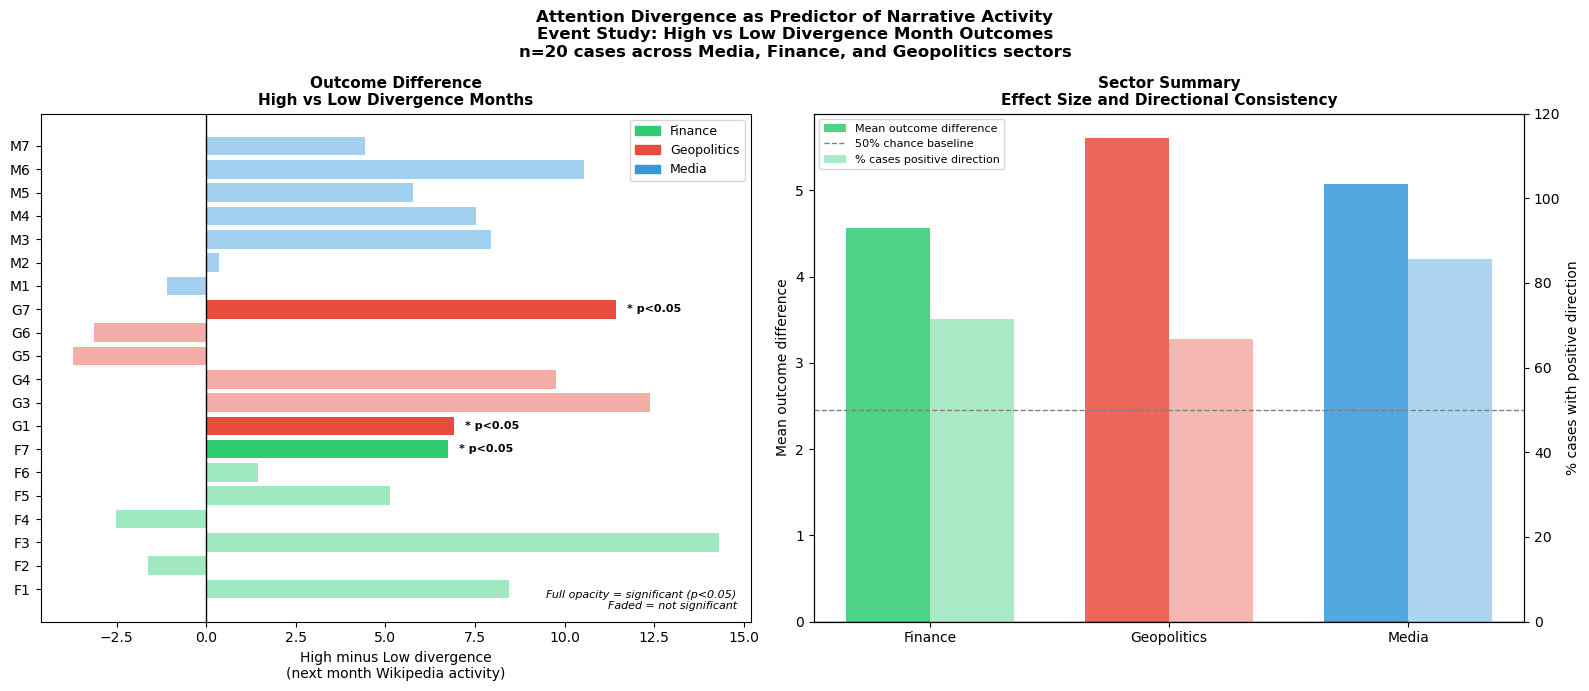

Saved: figures/event_study_summary.png


In [22]:
# CELL — Final summary figure

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np

results_df = pd.read_csv('data/processed/event_study_results.csv')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('white')

# ── LEFT PANEL: difference by case ───────────────────────────────
colors_sector = {
    'Finance':     '#2ECC71',
    'Geopolitics': '#E74C3C',
    'Media':       '#3498DB'
}

bar_colors = [
    colors_sector[s] for s in results_df['sector']
]
sig_alpha = [
    1.0 if s == 'YES' else 0.45
    for s in results_df['sig']
]

bars = ax1.barh(
    results_df['case_id'],
    results_df['difference'],
    color=bar_colors,
    alpha=0.8
)

# Adjust alpha per bar
for bar, alpha in zip(bars, sig_alpha):
    bar.set_alpha(alpha)

ax1.axvline(x=0, color='black', linewidth=1)
ax1.set_xlabel('High minus Low divergence\n(next month Wikipedia activity)',
               fontsize=10)
ax1.set_title('Outcome Difference\nHigh vs Low Divergence Months',
              fontsize=11, fontweight='bold')

# Mark significant cases
for i, (_, row) in enumerate(results_df.iterrows()):
    if row['sig'] == 'YES':
        ax1.text(row['difference'] + 0.3, i,
                 '* p<0.05', va='center', fontsize=8,
                 fontweight='bold')

legend_patches = [
    mpatches.Patch(color='#2ECC71', label='Finance'),
    mpatches.Patch(color='#E74C3C', label='Geopolitics'),
    mpatches.Patch(color='#3498DB', label='Media'),
]
ax1.legend(handles=legend_patches, fontsize=9)
ax1.text(0.98, 0.02,
         'Full opacity = significant (p<0.05)\nFaded = not significant',
         transform=ax1.transAxes, fontsize=8,
         ha='right', va='bottom', style='italic')

# ── RIGHT PANEL: sector summary ───────────────────────────────────
sector_summary = results_df.groupby('sector').agg(
    mean_diff=('difference', 'mean'),
    pct_positive=('difference', lambda x: (x > 0).mean() * 100)
).reset_index()

x = np.arange(len(sector_summary))
width = 0.35

bars1 = ax2.bar(x - width/2,
                sector_summary['mean_diff'],
                width, label='Mean outcome difference',
                color=[colors_sector[s]
                       for s in sector_summary['sector']],
                alpha=0.85)

ax2_twin = ax2.twinx()
bars2 = ax2_twin.bar(x + width/2,
                     sector_summary['pct_positive'],
                     width, label='% cases positive direction',
                     color=[colors_sector[s]
                            for s in sector_summary['sector']],
                     alpha=0.4)

ax2.set_xticks(x)
ax2.set_xticklabels(sector_summary['sector'], fontsize=10)
ax2.set_ylabel('Mean outcome difference', fontsize=10)
ax2_twin.set_ylabel('% cases with positive direction', fontsize=10)
ax2_twin.set_ylim(0, 120)
ax2.set_title('Sector Summary\nEffect Size and Directional Consistency',
              fontsize=11, fontweight='bold')

ax2.axhline(y=0, color='black', linewidth=1)
ax2_twin.axhline(y=50, color='grey', linewidth=1,
                 linestyle='--', label='50% chance baseline')

lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='upper left')

plt.suptitle(
    'Attention Divergence as Predictor of Narrative Activity\n'
    'Event Study: High vs Low Divergence Month Outcomes\n'
    'n=20 cases across Media, Finance, and Geopolitics sectors',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig('figures/event_study_summary.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figures/event_study_summary.png")

~ Study 2 — Final Summary ~

Title: Attention Signal Divergence as a Predictor of Narrative 
Activity Across Media, Finance, and Geopolitical Domains

Method: Wikipedia pageview activity and Google Trends search 
interest were collected for 21 entities across three sectors 
(Media n=7, Finance n=7, Geopolitics n=7) from January 2021 
through December 2023. A monthly divergence score was computed 
as the normalized difference between month-over-month changes 
in each signal. An event study approach compared Wikipedia 
narrative activity in months following high versus low divergence 
periods. Mann-Whitney U tests used throughout (Shapiro-Wilk 
confirmed non-normal distributions in all 20 cases).

Finding 1 - Directional consistency:
16 of 20 cases (80%) showed higher Wikipedia activity following 
high divergence months compared to low divergence months. 
This exceeds the 50% expected by chance and suggests a 
consistent directional effect across all three sectors.

Finding 2 - Statistical significance:
Three cases reached p<0.05: Silicon Valley Bank (F7, p=0.025), 
Ukraine/Russia-Ukraine War (G1, p=0.016), and Xi Jinping 
(G7, p=0.025). All three are geopolitical or financial entities 
with slow-building narrative structures.

Finding 3 - Sector differences:
Geopolitics showed the highest mean outcome difference (5.6), 
followed by Media (5.1) and Finance (4.6). The divergence 
signal appears stronger for geopolitical entities than 
financial or cultural ones.

~ Finding 4 — Event type taxonomy: ~
Visual analysis identified three distinct divergence signatures:
- Type 1 (Slow build): Wikipedia leads Trends before event, 
  Trends leads after. Predictive signal present. (GameStop, FTX)
- Type 2 (Simultaneous): Both signals activate together. 
  No predictive lead time. (Ukraine invasion)
- Type 3 (Trends dominant): Breaking news drives reactive 
  search first, Wikipedia follows. (Trump indictment, SVB)

Limitations:
- n=20-40 months per case — underpowered for robust inference
- Google Trends is relative not absolute
- Wikipedia not primary information platform in all markets
  (Korean audiences use Naver/Namu Wiki, not Wikipedia)
- Outcome variable (Wikipedia activity change) is a proxy 
  for narrative activity, not ground truth
- G2 (Palestine) excluded from statistical analysis (n=2 months)

Next steps (Study 2B):
Cross-cultural divergence analysis — does divergence between 
English Wikipedia and alt-language editions (Japanese, Korean, 
German, Chinese, Hebrew, Russian) predict outcomes with 
different lead times or strengths than within-language divergence?